# Análise de valores ausentes

Este notebook complementa o relatório gerado pelo ETL (`outputs/relatorio_missing_values.csv`), com leitura programática e visualizações. Execute o ETL antes para atualizar os artefatos.

**Referência:** `docs/politica_dados_ausentes.md`

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "etl").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from etl.missing_report import load_missing_report_bundle, OUTPUT_DIR, FIG_DIR

path_rel = OUTPUT_DIR / "relatorio_missing_values.csv"
assert path_rel.exists(), "Execute antes: python etl/etl_pipeline.py"
bundle = load_missing_report_bundle(path_rel)
resumo = bundle["resumo_global"]
formas = bundle["formas"]
detalhe = bundle["detalhe"]
resumo, formas.head()

(                      tabela  total_celulas  total_ausentes  \
 0       socioeconomico_bruta            585              15   
 1          educacional_bruta           3705             605   
 2  fato_integrado_processada           2548             175   
 
    pct_ausentes_global  
 0               2.5641  
 1              16.3293  
 2               6.8681  ,
                    fonte                             etapa  n_linhas  \
 0         socioeconomica                             bruta        65   
 1            educacional                             bruta       247   
 2         socioeconomica  processada (fato_socioeconomico)        51   
 3            educacional     processada (fato_educacional)       127   
 4  integracao_escola_ano       processada (fato_integrado)        98   
 
    n_colunas  
 0          9  
 1         15  
 2         10  
 3         19  
 4         26  )

## Resumo global e formas (antes vs depois do ETL)

O bloco **RESUMO_FORMAS** do CSV registra `n_linhas` e `n_colunas` das bases brutas e das tabelas processadas correspondentes.

In [2]:
from IPython.display import display

display(formas)
print("Total de células ausentes (resumo global):")
display(resumo)

,fonte,etapa,n_linhas,n_colunas
0,socioeconomica,bruta,65,9
1,educacional,bruta,247,15
2,socioeconomica,processada (fato_socioeconomico),51,10
3,educacional,processada (fato_educacional),127,19
4,integracao_escola_ano,processada (fato_integrado),98,26


Total de células ausentes (resumo global):


,tabela,total_celulas,total_ausentes,pct_ausentes_global
0,socioeconomico_bruta,585,15,2.5641
1,educacional_bruta,3705,605,16.3293
2,fato_integrado_processada,2548,175,6.8681


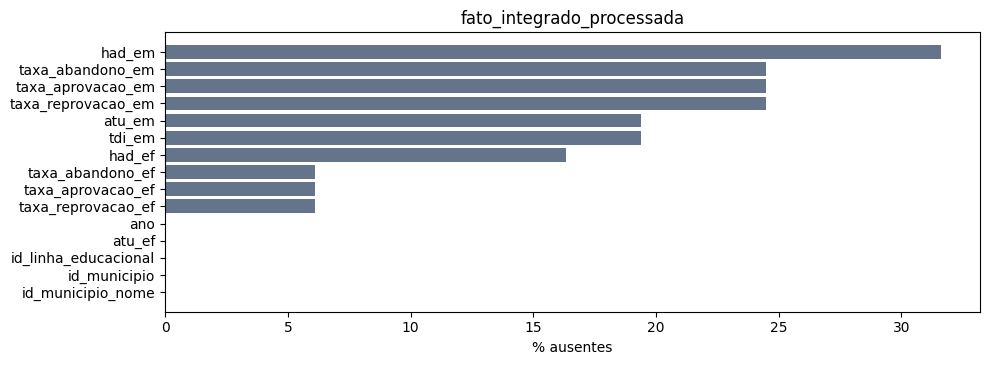

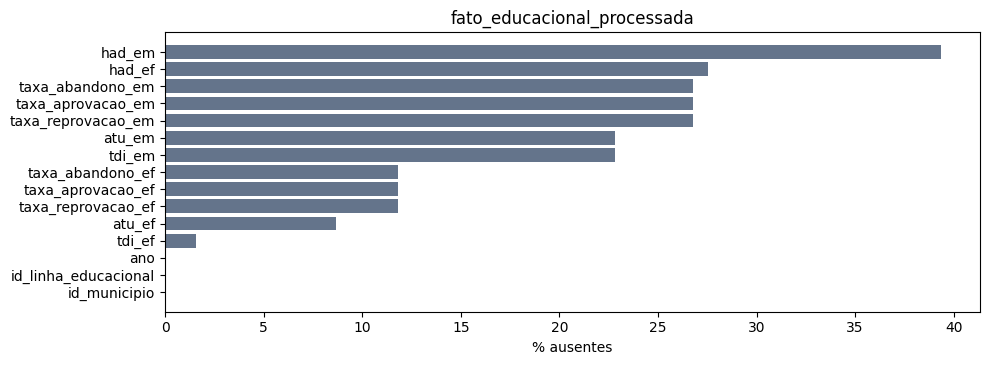

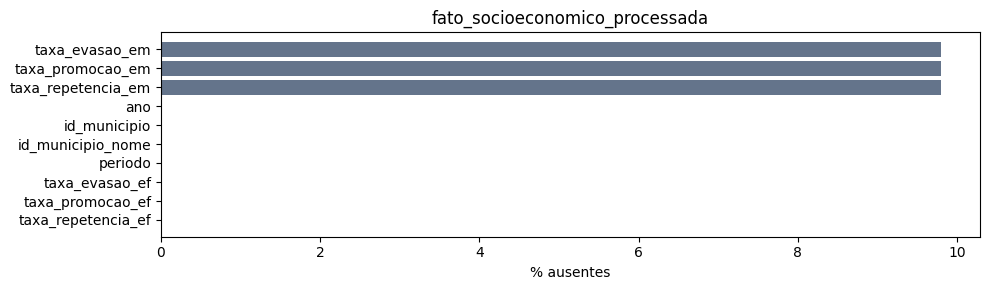

In [3]:
def plot_top_missing(sub: pd.DataFrame, title: str, top_n: int = 15):
    sub = sub.sort_values("pct_ausentes", ascending=False).head(top_n)
    if sub.empty:
        print("Sem ausentes neste recorte.")
        return
    fig, ax = plt.subplots(figsize=(10, max(3, 0.25 * len(sub))))
    ax.barh(sub["coluna"][::-1], sub["pct_ausentes"][::-1], color="#64748B")
    ax.set_xlabel("% ausentes")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

for nome_fato in ["fato_integrado_processada", "fato_educacional_processada", "fato_socioeconomico_processada"]:
    dsub = detalhe[detalhe["tabela"] == nome_fato]
    plot_top_missing(dsub, nome_fato)

## Figuras exportadas pelo ETL

Se `matplotlib`/`seaborn` estiverem disponíveis na execução do ETL, imagens são salvas em `outputs/figures/` (heatmap amostral e barras).

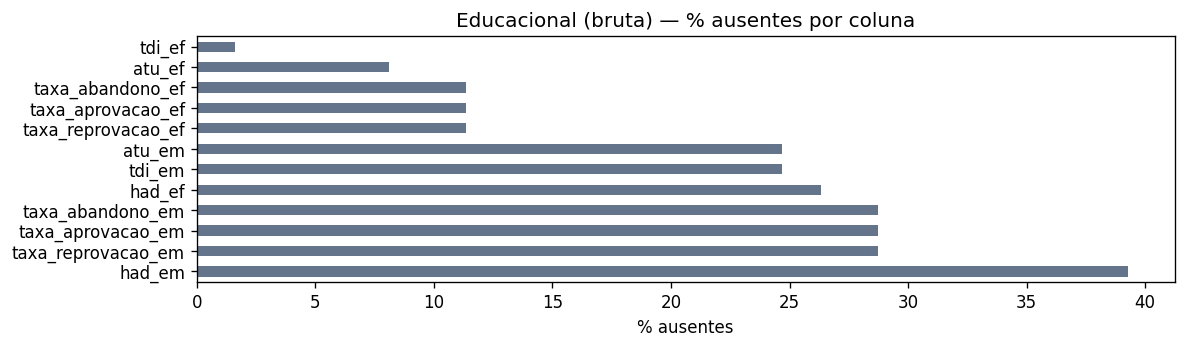

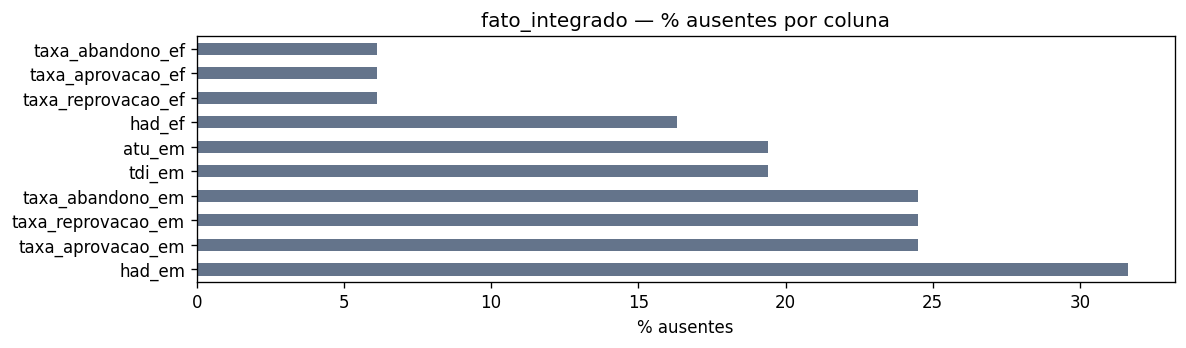

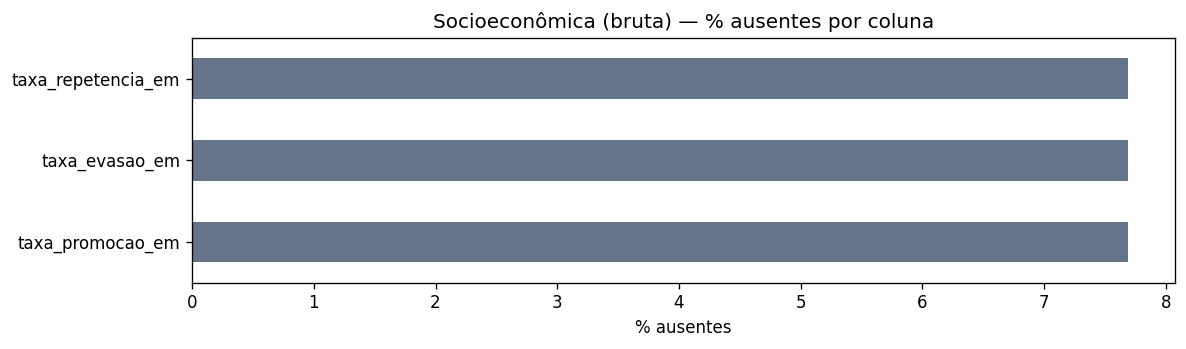

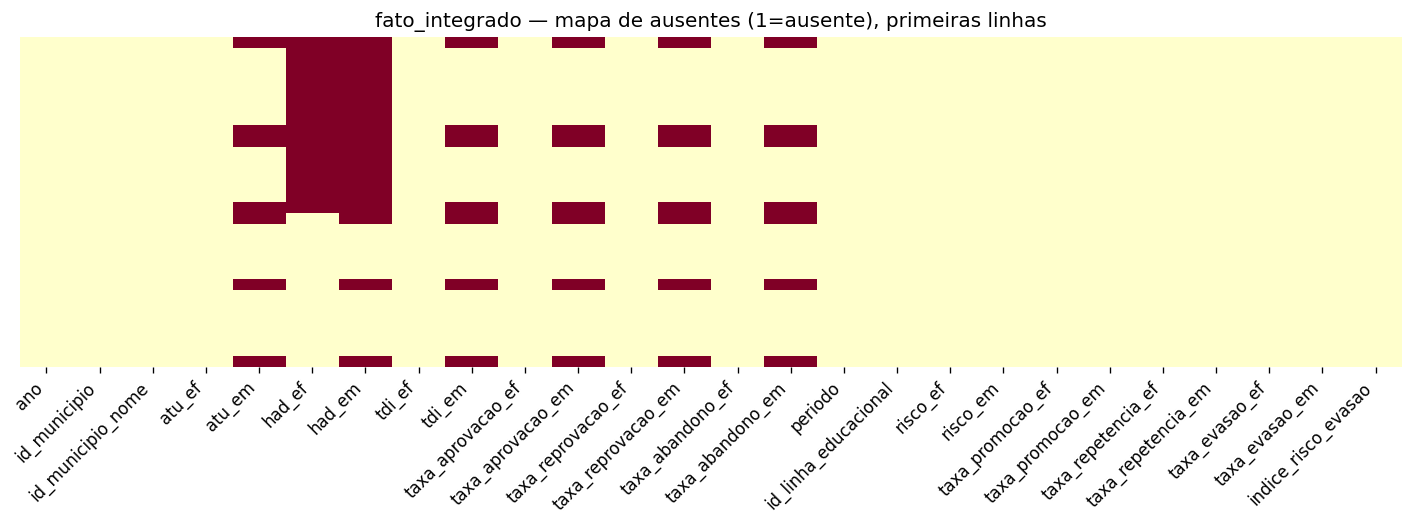

In [4]:
from IPython.display import Image, display

figs = sorted(FIG_DIR.glob("missing_*.png"))
if not figs:
    print("Nenhuma figura em outputs/figures/ — execute o ETL com matplotlib/seaborn instalados.")
else:
    for png in figs:
        display(Image(filename=str(png)))

## Impacto no modelo (baseline)

Compara Ridge com **todas** as covariáveis (imputação no Pipeline, fit só no treino) versus modelo **sem** colunas com taxa de ausência no treino acima do limiar.

In [5]:
from ml.baseline_municipio import run_missing_impact_analysis

impact = run_missing_impact_analysis(sparse_threshold=0.5)
pd.DataFrame([impact["metrics_ridge_all_features"], impact["metrics_ridge_without_sparse_columns"]],
             index=["ridge_todas_features", "ridge_sem_colunas_esparsas"])

,mae,rmse,r2
ridge_todas_features,0.853852,1.108685,0.774804
ridge_sem_colunas_esparsas,0.853852,1.108685,0.774804


## Insights interpretativos (qualidade e contexto)

- **Causas frequentes de ausência:** indicador não divulgado na agregação do INEP para certo ano; mudanças metodológicas entre coleções; células suprimidas em bases públicas.
- **Pandemia (2020–2021):** distúrbios no censo escolar e ensino remoto podem aumentar lacunas ou alterar a comparabilidade dos indicadores — interpretar séries com cautela.
- **Limitação:** imputação no sklearn permite estimar o modelo, mas **não recupera informação que a fonte não coletou**; previsões em anos ou escolas muito incompletos são menos fiáveis.

Ver também o expander **Qualidade dos dados e valores ausentes** na barra lateral do dashboard Streamlit.

## Resumo final (checklist)

- Totais de ausentes: tabela `resumo_global` acima.
- Colunas mais problemáticas: ranking em `detalhe` (`rank_no_dataset`) por tabela.
- Estratégia: ETL preserva `NaN`; índice de risco com pesos renormalizados; ML com `SimpleImputer` no Pipeline (treino apenas).
- Conjunto do modelo: `fato_integrado` — ver `run_missing_impact_analysis` para linhas com algum ausente em X e comparação de métricas.